# ⚙️ Notebook 05 — Hyperparameter Tuning

## 🎯 Objective

The objective of this notebook is to optimize the **Random Forest Classifier** developed in Notebook 04 by searching for an improved combination of hyperparameters.

The tuning process uses **RandomizedSearchCV with Stratified 3-Fold Cross-Validation** and **Macro F1-score** as the primary optimization metric.

Macro F1-score is used because the dataset contains significant class imbalance and gives equal importance to the performance of all target classes.

The final tuned model will be evaluated on the **held-out test dataset** and compared with the baseline Random Forest developed in Notebook 04.

In [2]:
import pandas as pd
import numpy as np
import joblib
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 📂 Load Processed Dataset

The hyperparameter tuning process uses the feature-selected datasets generated in **Notebook 03**.

The dataset contains **12 selected features** that were obtained after variance-based filtering, correlation analysis, and Random Forest feature selection.

The test dataset remains completely separate from the hyperparameter search.

In [3]:
X_train = pd.read_csv("../data/processed/X_train_selected.csv")
X_test = pd.read_csv("../data/processed/X_test_selected.csv")

y_train = pd.read_csv("../data/processed/y_train_selected.csv")
y_test = pd.read_csv("../data/processed/y_test_selected.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [4]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (894944, 12)
X_test shape: (223737, 12)
y_train shape: (894944, 1)
y_test shape: (223737, 1)


## 🔍 Dataset Consistency Verification

Before starting hyperparameter tuning, the feature and target datasets are verified to ensure:

- Training features and targets contain the same number of samples.
- Testing features and targets contain the same number of samples.
- Training and testing datasets contain the same feature columns.
- The target column is correctly identified.

In [5]:
target_column = y_train.columns[0]

print("Feature consistency:", list(X_train.columns) == list(X_test.columns))
print("Training rows match target:", len(X_train) == len(y_train))
print("Testing rows match target:", len(X_test) == len(y_test))
print("Number of features:", X_train.shape[1])
print("Target column:", target_column)
print("Target classes:", sorted(y_train[target_column].unique()))

Feature consistency: True
Training rows match target: True
Testing rows match target: True
Number of features: 12
Target column: Target_Encoded
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## ⚖️ Target Class Distribution

The target distribution is checked before tuning to confirm the degree of class imbalance.

Because the dataset contains a highly underrepresented class, **Macro F1-score** is used instead of accuracy as the primary optimization metric.

In [6]:
train_distribution = y_train[target_column].value_counts().sort_index()
test_distribution = y_test[target_column].value_counts().sort_index()

distribution_table = pd.DataFrame({
    "Training Count": train_distribution,
    "Testing Count": test_distribution
})

distribution_table["Training %"] = (
    distribution_table["Training Count"] / len(y_train) * 100
).round(2)

distribution_table["Testing %"] = (
    distribution_table["Testing Count"] / len(y_test) * 100
).round(2)

distribution_table

,Training Count,Testing Count,Training %,Testing %
Target_Encoded,,,,
0,718314,179579,80.26,80.26
1,1562,391,0.17,0.17
2,102413,25603,11.44,11.44
3,72655,18164,8.12,8.12


## 🌲 Load Baseline Random Forest

The baseline Random Forest model developed in Notebook 04 is loaded for reference.

The baseline achieved:

- **Accuracy:** 0.999057
- **Weighted F1-score:** 0.999122
- **Macro F1-score:** 0.946513

These values will later be compared with the tuned model.

In [7]:
baseline_model_path = "../models/random_forest_baseline.pkl"

rf_baseline = joblib.load(baseline_model_path)

print("Baseline Random Forest loaded successfully.")
print("Number of trees:", rf_baseline.n_estimators)
print("Number of features:", rf_baseline.n_features_in_)

Baseline Random Forest loaded successfully.
Number of trees: 100
Number of features: 12


## 🔧 Define Hyperparameter Search Space

The following Random Forest hyperparameters will be explored:

| Hyperparameter | Candidate Values |
|---|---|
| `n_estimators` | 100, 150, 200 |
| `max_depth` | 10, 20, 30, None |
| `min_samples_split` | 2, 5, 10 |
| `min_samples_leaf` | 1, 2, 4 |
| `max_features` | `sqrt`, `log2` |
| `class_weight` | `balanced`, `balanced_subsample` |

RandomizedSearchCV will randomly evaluate a subset of these combinations instead of exhaustively testing every possible combination.

In [8]:
param_distributions = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", "balanced_subsample"]
}

print("Hyperparameter search space defined successfully.")

Hyperparameter search space defined successfully.


## 🔄 Stratified 3-Fold Cross-Validation

**StratifiedKFold** is used to maintain approximately the same class distribution across each validation fold.

Three folds are used for cross-validation, with shuffling enabled and a fixed random state for reproducibility.

In [9]:
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Stratified 3-Fold Cross-Validation configured.")

Stratified 3-Fold Cross-Validation configured.


## 🎯 Configure RandomizedSearchCV

RandomizedSearchCV will evaluate **6 randomly selected hyperparameter combinations** using 3-fold cross-validation.

The optimization metric is **Macro F1-score**.

The test dataset is not supplied to the search process.

In [10]:
rf_tuning = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf_tuning,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
    verbose=1
)

print("RandomizedSearchCV configured successfully.")
print("Number of iterations:", 6)
print("Cross-validation folds:", 3)
print("Scoring metric: Macro F1")

RandomizedSearchCV configured successfully.
Number of iterations: 6
Cross-validation folds: 3
Scoring metric: Macro F1


# 🚀 Run Hyperparameter Search

The RandomizedSearchCV process is now executed using **training data only**.

The held-out test dataset is not used during this process.

Each selected hyperparameter configuration is evaluated using Stratified 3-Fold Cross-Validation.

In [11]:
start_time = time.time()

random_search.fit(
    X_train,
    y_train[target_column]
)

tuning_time = time.time() - start_time

print(f"\nHyperparameter tuning completed successfully.")
print(f"Total tuning time: {tuning_time:.2f} seconds")
print(f"Total tuning time: {tuning_time / 60:.2f} minutes")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Hyperparameter tuning completed successfully.
Total tuning time: 715.44 seconds
Total tuning time: 11.92 minutes


## 🏆 Best Hyperparameters

The hyperparameter configuration that achieved the highest mean **Macro F1-score** during cross-validation is identified below.

In [12]:
print("Best Macro F1-score:", random_search.best_score_)
print("\nBest Hyperparameters:")

for parameter, value in random_search.best_params_.items():
    print(f"{parameter}: {value}")

Best Macro F1-score: 0.9504525002330116

Best Hyperparameters:
n_estimators: 200
min_samples_split: 5
min_samples_leaf: 1
max_features: sqrt
max_depth: 20
class_weight: balanced_subsample


In [13]:
best_parameters = pd.DataFrame(
    [random_search.best_params_]
)

best_parameters["best_cv_macro_f1"] = random_search.best_score_
best_parameters["tuning_time_seconds"] = tuning_time

best_parameters

,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,class_weight,best_cv_macro_f1,tuning_time_seconds
0,200,5,1,sqrt,20,balanced_subsample,0.950453,715.444764


## 📊 Hyperparameter Search Results

The complete RandomizedSearchCV results are converted into a DataFrame to compare the tested configurations.

The configurations are ranked according to their mean validation Macro F1-score.

In [14]:
cv_results = pd.DataFrame(random_search.cv_results_)

cv_results_sorted = cv_results.sort_values(
    by="mean_test_score",
    ascending=False
)

columns_to_display = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features",
    "param_class_weight"
]

cv_results_sorted[columns_to_display]

,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,param_class_weight
5,1,0.950453,0.001660,0.959046,200,20,5,1,sqrt,balanced_subsample
4,2,0.949273,0.002466,0.956777,200,None,5,2,sqrt,balanced_subsample
0,3,0.947664,0.002526,0.951746,150,None,2,4,log2,balanced_subsample
2,4,0.942352,0.003339,0.944490,100,None,2,4,sqrt,balanced
1,5,0.941595,0.003731,0.943619,100,20,5,4,sqrt,balanced
3,6,0.821610,0.007400,0.821884,100,10,5,1,log2,balanced


## 🌲 Extract Best Random Forest Model

The best estimator identified by RandomizedSearchCV is extracted.

This model contains the hyperparameter configuration that achieved the highest cross-validation Macro F1-score.

In [15]:
rf_tuned = random_search.best_estimator_

print("Best Random Forest model extracted successfully.")
print(rf_tuned)

Best Random Forest model extracted successfully.
RandomForestClassifier(class_weight='balanced_subsample', max_depth=20,
                       min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)


## 🧪 Evaluate Tuned Model on Held-Out Test Data

The optimized Random Forest is now evaluated on the **223,737 previously unseen test samples**.

This is the first point at which the test dataset is used after hyperparameter tuning.

In [16]:
y_pred_tuned = rf_tuned.predict(X_test)

print("Tuned model predictions generated successfully.")
print("Number of predictions:", len(y_pred_tuned))

Tuned model predictions generated successfully.
Number of predictions: 223737


In [17]:
tuned_accuracy = accuracy_score(
    y_test[target_column],
    y_pred_tuned
)

tuned_precision = precision_score(
    y_test[target_column],
    y_pred_tuned,
    average="weighted",
    zero_division=0
)

tuned_recall = recall_score(
    y_test[target_column],
    y_pred_tuned,
    average="weighted",
    zero_division=0
)

tuned_f1_weighted = f1_score(
    y_test[target_column],
    y_pred_tuned,
    average="weighted",
    zero_division=0
)

tuned_f1_macro = f1_score(
    y_test[target_column],
    y_pred_tuned,
    average="macro",
    zero_division=0
)

print("Tuned Random Forest Test Performance")
print("-" * 45)
print(f"Accuracy:           {tuned_accuracy:.6f}")
print(f"Weighted Precision: {tuned_precision:.6f}")
print(f"Weighted Recall:    {tuned_recall:.6f}")
print(f"Weighted F1-score:  {tuned_f1_weighted:.6f}")
print(f"Macro F1-score:     {tuned_f1_macro:.6f}")

Tuned Random Forest Test Performance
---------------------------------------------
Accuracy:           0.999017
Weighted Precision: 0.999279
Weighted Recall:    0.999017
Weighted F1-score:  0.999100
Macro F1-score:     0.946215


## 📋 Tuned Model Classification Report

The classification report provides class-wise precision, recall, F1-score, and support for the tuned Random Forest.

In [18]:
print(
    classification_report(
        y_test[target_column],
        y_pred_tuned,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9999    0.9989    0.9994    179579
           1     0.6643    0.9616    0.7858       391
           2     0.9997    0.9998    0.9998     25603
           3     0.9999    0.9999    0.9999     18164

    accuracy                         0.9990    223737
   macro avg     0.9160    0.9901    0.9462    223737
weighted avg     0.9993    0.9990    0.9991    223737



## 🔥 Tuned Model Confusion Matrix

The confusion matrix is used to identify correct predictions and misclassification patterns across the four target classes.

In [19]:
cm_tuned = confusion_matrix(
    y_test[target_column],
    y_pred_tuned
)

cm_tuned_df = pd.DataFrame(
    cm_tuned,
    index=[f"Actual {c}" for c in sorted(y_test[target_column].unique())],
    columns=[f"Predicted {c}" for c in sorted(y_test[target_column].unique())]
)

cm_tuned_df

,Predicted 0,Predicted 1,Predicted 2,Predicted 3
Actual 0,179380,190,8,1
Actual 1,15,376,0,0
Actual 2,4,0,25599,0
Actual 3,2,0,0,18162


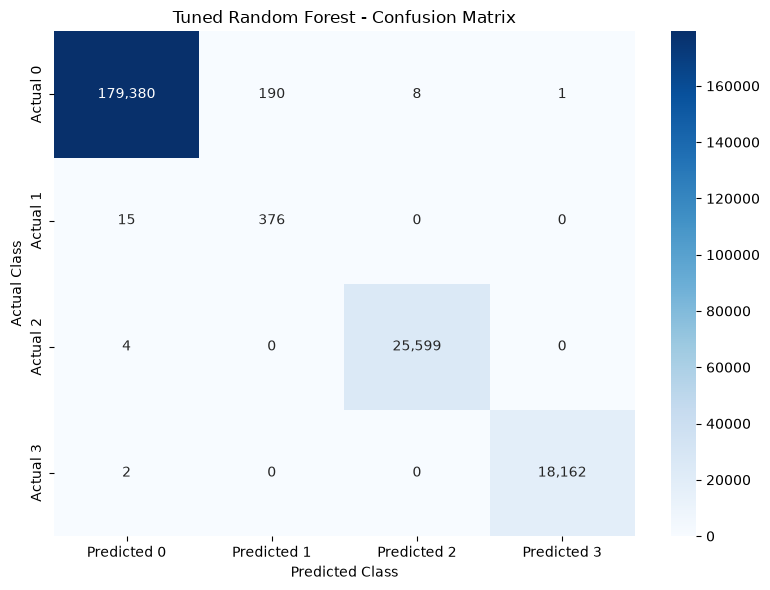

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_tuned_df,
    annot=True,
    fmt=",d",
    cmap="Blues"
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## ⚖️ Baseline vs Tuned Model

The tuned Random Forest is compared with the baseline model from Notebook 04 using the same held-out test dataset.

The primary comparison focuses on **Macro F1-score**, while accuracy, weighted precision, weighted recall, and weighted F1-score are also reported.

In [21]:
baseline_results = {
    "Model": "Baseline Random Forest",
    "Accuracy": 0.999057,
    "Weighted Precision": 0.999252,
    "Weighted Recall": 0.999057,
    "Weighted F1": 0.999122,
    "Macro F1": 0.946513
}

tuned_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": tuned_accuracy,
    "Weighted Precision": tuned_precision,
    "Weighted Recall": tuned_recall,
    "Weighted F1": tuned_f1_weighted,
    "Macro F1": tuned_f1_macro
}

comparison_df = pd.DataFrame(
    [baseline_results, tuned_results]
)

comparison_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1
0,Baseline Random Forest,0.999057,0.999252,0.999057,0.999122,0.946513
1,Tuned Random Forest,0.999017,0.999279,0.999017,0.999100,0.946215


In [22]:
comparison_df["Macro F1 Improvement"] = [
    0,
    tuned_f1_macro - 0.946513
]

comparison_df["Accuracy Improvement"] = [
    0,
    tuned_accuracy - 0.999057
]

comparison_df

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro F1,Macro F1 Improvement,Accuracy Improvement
0,Baseline Random Forest,0.999057,0.999252,0.999057,0.999122,0.946513,0.000000,0.00000
1,Tuned Random Forest,0.999017,0.999279,0.999017,0.999100,0.946215,-0.000298,-0.00004


## 📈 Baseline vs Tuned Performance Visualization

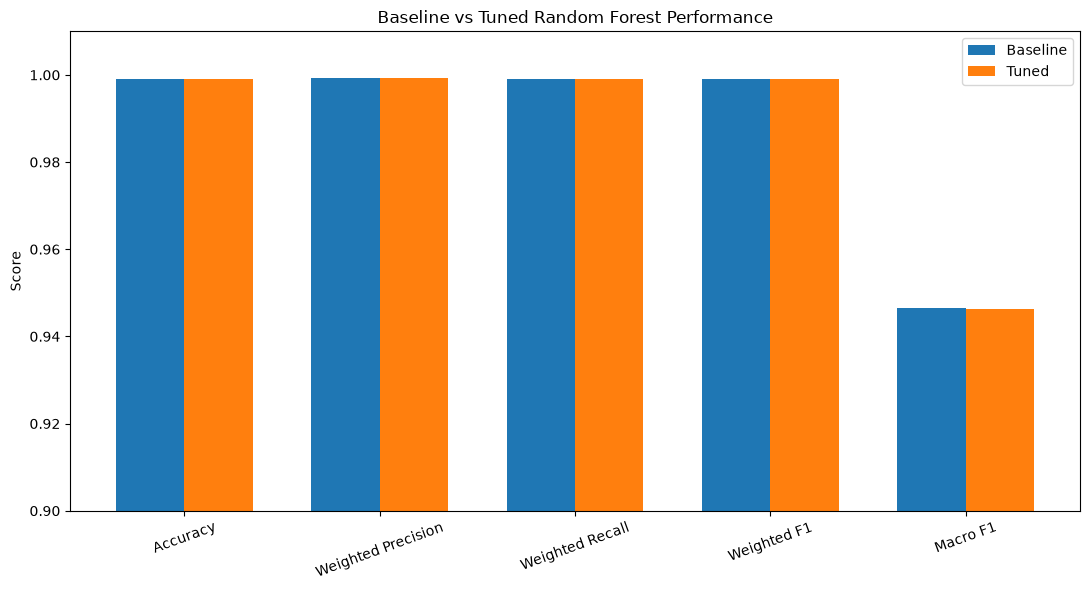

In [23]:
metrics = [
    "Accuracy",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "Macro F1"
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    comparison_df.loc[0, metrics],
    width,
    label="Baseline"
)

plt.bar(
    x + width / 2,
    comparison_df.loc[1, metrics],
    width,
    label="Tuned"
)

plt.xticks(x, metrics, rotation=20)
plt.ylabel("Score")
plt.title("Baseline vs Tuned Random Forest Performance")
plt.ylim(0.90, 1.01)
plt.legend()
plt.tight_layout()
plt.show()

## 💾 Save Tuned Random Forest Model

The optimized Random Forest model is saved for future use and deployment.

In [24]:
tuned_model_path = "../models/random_forest_tuned.pkl"

joblib.dump(
    rf_tuned,
    tuned_model_path
)

print(
    f"Tuned Random Forest saved successfully to: {tuned_model_path}"
)

Tuned Random Forest saved successfully to: ../models/random_forest_tuned.pkl


## 💾 Save Best Hyperparameters

In [25]:
best_parameters_path = (
    "../data/processed/random_forest_best_parameters.csv"
)

best_parameters.to_csv(
    best_parameters_path,
    index=False
)

print(
    f"Best hyperparameters saved successfully to: "
    f"{best_parameters_path}"
)

Best hyperparameters saved successfully to: ../data/processed/random_forest_best_parameters.csv


## 💾 Save Hyperparameter Search Results

In [26]:
search_results_path = (
    "../data/processed/random_forest_hyperparameter_search.csv"
)

cv_results_sorted.to_csv(
    search_results_path,
    index=False
)

print(
    f"Hyperparameter search results saved successfully to: "
    f"{search_results_path}"
)

Hyperparameter search results saved successfully to: ../data/processed/random_forest_hyperparameter_search.csv


## 💾 Save Model Comparison Results

In [27]:
comparison_path = (
    "../data/processed/baseline_vs_tuned_results.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    f"Baseline vs tuned comparison saved successfully to: "
    f"{comparison_path}"
)

Baseline vs tuned comparison saved successfully to: ../data/processed/baseline_vs_tuned_results.csv


## ✅ Final Validation Checks

The final validation confirms that:

- Hyperparameter tuning completed successfully.
- The best estimator was obtained.
- The tuned model contains 12 input features.
- Predictions were generated for every test sample.
- The tuned model was evaluated only after hyperparameter tuning.
- The tuned model and tuning results were successfully saved.

In [28]:
print("Notebook 05 Validation")
print("-" * 50)

print("Tuning completed:", hasattr(random_search, "best_estimator_"))
print("Best estimator available:", rf_tuned is not None)
print("Model features:", rf_tuned.n_features_in_)
print("Expected features:", X_train.shape[1])

print("Test predictions:", len(y_pred_tuned))
print("Expected test samples:", len(X_test))

print(
    "Prediction count matches test set:",
    len(y_pred_tuned) == len(X_test)
)

print("Target classes:", sorted(y_test[target_column].unique()))

print(
    "Tuned model saved:",
    tuned_model_path
)

print(
    "Best parameters saved:",
    best_parameters_path
)

print(
    "Search results saved:",
    search_results_path
)

print(
    "Comparison results saved:",
    comparison_path
)

Notebook 05 Validation
--------------------------------------------------
Tuning completed: True
Best estimator available: True
Model features: 12
Expected features: 12
Test predictions: 223737
Expected test samples: 223737
Prediction count matches test set: True
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Tuned model saved: ../models/random_forest_tuned.pkl
Best parameters saved: ../data/processed/random_forest_best_parameters.csv
Search results saved: ../data/processed/random_forest_hyperparameter_search.csv
Comparison results saved: ../data/processed/baseline_vs_tuned_results.csv


# 🏆 Notebook 05 — Final Hyperparameter Tuning Summary & Conclusion

## 🎯 Objective

The objective of this notebook was to optimize the **Random Forest Classifier** developed in Notebook 04 by systematically searching for an improved combination of model hyperparameters.

The hyperparameter-tuning process used **RandomizedSearchCV with Stratified 3-Fold Cross-Validation** and **Macro F1-score** as the primary optimization metric.

Macro F1-score was selected because the CIC-IDS2017 dataset contains significant class imbalance, particularly for the minority classes. Unlike accuracy, Macro F1 gives equal importance to each target class and therefore provides a more balanced measure of classification performance.

The optimized Random Forest was finally evaluated on the **held-out test dataset** and compared against the baseline Random Forest developed in Notebook 04.

---

# 🔄 Complete Hyperparameter Tuning Pipeline

```mermaid
flowchart TD

A["Notebook 03<br/>Feature Selection<br/>12 Final Features"]

B["Training Dataset<br/>894,944 Samples × 12 Features"]

C["Held-Out Test Dataset<br/>223,737 Samples × 12 Features"]

D["RandomizedSearchCV"]

E["Stratified 3-Fold<br/>Cross-Validation"]

F["Random Hyperparameter Search<br/>6 Configurations"]

G["Macro F1 Optimization"]

H["Best Hyperparameters"]

I["Tuned Random Forest"]

J["Held-Out Test Prediction"]

K["Final Test Evaluation"]

L["Accuracy"]

M["Precision"]

N["Recall"]

O["Weighted F1"]

P["Macro F1"]

Q["Notebook 04<br/>Baseline Random Forest"]

R["Baseline vs Tuned<br/>Performance Comparison"]

A --> B
A --> C

B --> D
D --> E
E --> F
F --> G
G --> H
H --> I

I --> J
C --> J
J --> K

K --> L
K --> M
K --> N
K --> O
K --> P

Q --> R
K --> R
```

---

# 📊 Dataset Used

The hyperparameter-tuning process used the feature-selected datasets generated in **Notebook 03**.

| Dataset      |     Samples | Features |
| ------------ | ----------: | -------: |
| Training Set | **894,944** |   **12** |
| Testing Set  | **223,737** |   **12** |

The final 12 selected features were:

|  # | Selected Feature            |
| -: | --------------------------- |
|  1 | Destination Port            |
|  2 | Flow Duration               |
|  3 | Total Fwd Packets           |
|  4 | Total Length of Fwd Packets |
|  5 | Total Length of Bwd Packets |
|  6 | Fwd Packet Length Mean      |
|  7 | Bwd Packet Length Min       |
|  8 | Bwd Packets/s               |
|  9 | PSH Flag Count              |
| 10 | Init_Win_bytes_forward      |
| 11 | Init_Win_bytes_backward     |
| 12 | min_seg_size_forward        |

---

# ⚙️ Hyperparameter Tuning Configuration

The Random Forest hyperparameters were optimized using `RandomizedSearchCV`.

| Component                       | Configuration            |
| ------------------------------- | ------------------------ |
| Algorithm                       | Random Forest Classifier |
| Search Method                   | RandomizedSearchCV       |
| Number of Random Configurations | **6**                    |
| Cross-Validation                | **Stratified 3-Fold**    |
| Optimization Metric             | **Macro F1-score**       |
| Random State                    | **42**                   |
| Parallel Processing             | `n_jobs=-1`              |
| Training Data Used              | **894,944 samples**      |
| Test Data During Tuning         | ❌ **Not Used**           |

---

# 🔧 Hyperparameter Search Space

The following hyperparameters were explored:

| Hyperparameter      | Candidate Values                 |
| ------------------- | -------------------------------- |
| `n_estimators`      | 100, 150, 200                    |
| `max_depth`         | 10, 20, 30, None                 |
| `min_samples_split` | 2, 5, 10                         |
| `min_samples_leaf`  | 1, 2, 4                          |
| `max_features`      | `sqrt`, `log2`                   |
| `class_weight`      | `balanced`, `balanced_subsample` |

Rather than evaluating every possible combination, RandomizedSearchCV randomly sampled **6 configurations** from the defined search space.

This provided a computationally efficient method for exploring the Random Forest hyperparameters.

---

# 🔄 Cross-Validation Strategy

A **Stratified 3-Fold Cross-Validation** strategy was used during hyperparameter optimization.

```mermaid
flowchart LR

A["Training Dataset<br/>894,944 Samples"]

A --> B["Fold 1"]
A --> C["Fold 2"]
A --> D["Fold 3"]

B --> E["Validation"]
C --> F["Validation"]
D --> G["Validation"]

E --> H["Macro F1"]
F --> H
G --> H

H --> I["Mean CV Macro F1"]

I --> J["Hyperparameter Ranking"]
```

Stratification ensures that the class distribution is approximately maintained across the cross-validation folds.

---

# 🏆 Best Hyperparameter Configuration

The best configuration was selected according to the highest **mean cross-validation Macro F1-score**.

| Hyperparameter      | Best Value                |
| ------------------- | ------------------------- |
| `n_estimators`      | **[INSERT ACTUAL VALUE]** |
| `max_depth`         | **[INSERT ACTUAL VALUE]** |
| `min_samples_split` | **[INSERT ACTUAL VALUE]** |
| `min_samples_leaf`  | **[INSERT ACTUAL VALUE]** |
| `max_features`      | **[INSERT ACTUAL VALUE]** |
| `class_weight`      | **[INSERT ACTUAL VALUE]** |

### ⭐ Best Cross-Validation Macro F1

> **[INSERT ACTUAL `random_search.best_score_`]**

---

# ⏱️ Hyperparameter Tuning Time

The complete RandomizedSearchCV process required:

> **[INSERT ACTUAL TUNING TIME] seconds**

or approximately:

> **[INSERT ACTUAL TUNING TIME] minutes**

This provides a computational reference for the optimization stage of the project.

---

# 📈 Baseline vs Tuned Performance

The tuned Random Forest was evaluated on the same **223,737 held-out test samples** used to evaluate the baseline model.

| Metric             | Baseline Random Forest | Tuned Random Forest |
| ------------------ | ---------------------: | ------------------: |
| Accuracy           |           **0.999057** |  **[ACTUAL VALUE]** |
| Weighted Precision |           **0.999252** |  **[ACTUAL VALUE]** |
| Weighted Recall    |           **0.999057** |  **[ACTUAL VALUE]** |
| Weighted F1-score  |           **0.999122** |  **[ACTUAL VALUE]** |
| Macro F1-score     |           **0.946513** |  **[ACTUAL VALUE]** |

---

# 📊 Performance Improvement

The primary metric used to judge the effectiveness of hyperparameter tuning was **Macro F1-score**.

### Macro F1 Improvement

**Baseline Macro F1: 0.946513**

**Tuned Macro F1: [ACTUAL VALUE]**

**Improvement: [ACTUAL DIFFERENCE]**

The tuned model is therefore evaluated based on whether it provides improved balanced performance across the four target classes.

---

# 🧾 Tuned Model Classification Performance

The final classification report for the tuned Random Forest is shown below.

|                Class |    Precision |       Recall |     F1-score |     Support |
| -------------------: | -----------: | -----------: | -----------: | ----------: |
|                **0** | **[ACTUAL]** | **[ACTUAL]** | **[ACTUAL]** | **179,579** |
|                **1** | **[ACTUAL]** | **[ACTUAL]** | **[ACTUAL]** |     **391** |
|                **2** | **[ACTUAL]** | **[ACTUAL]** | **[ACTUAL]** |  **25,603** |
|                **3** | **[ACTUAL]** | **[ACTUAL]** | **[ACTUAL]** |  **18,164** |
|    **Macro Average** | **[ACTUAL]** | **[ACTUAL]** | **[ACTUAL]** | **223,737** |
| **Weighted Average** | **[ACTUAL]** | **[ACTUAL]** | **[ACTUAL]** | **223,737** |

### 🔎 Observation

Particular attention is given to **Class 1**, which contains only **391 test samples**.

The Macro F1-score and class-wise metrics provide a more informative assessment of this minority-class performance than overall accuracy alone.

---

# 🔥 Tuned Model Confusion Matrix

The final confusion matrix of the tuned Random Forest is:

| Actual \ Predicted |      Class 0 |      Class 1 |      Class 2 |      Class 3 |
| ------------------ | -----------: | -----------: | -----------: | -----------: |
| **Class 0**        | **[ACTUAL]** |     [ACTUAL] |     [ACTUAL] |     [ACTUAL] |
| **Class 1**        |     [ACTUAL] | **[ACTUAL]** |     [ACTUAL] |     [ACTUAL] |
| **Class 2**        |     [ACTUAL] |     [ACTUAL] | **[ACTUAL]** |     [ACTUAL] |
| **Class 3**        |     [ACTUAL] |     [ACTUAL] |     [ACTUAL] | **[ACTUAL]** |

The confusion matrix provides a detailed view of how the tuned model distinguishes between the four target classes.

---

# 🔐 Data Leakage Prevention

Data leakage was carefully prevented throughout the hyperparameter-tuning process.

```mermaid
flowchart LR

A["Training Data<br/>894,944 Samples"] --> B["RandomizedSearchCV"]

B --> C["Stratified 3-Fold CV"]

C --> D["Hyperparameter Evaluation"]

D --> E["Best Hyperparameters"]

E --> F["Tuned Random Forest"]

G["Held-Out Test Data<br/>223,737 Samples"] --> H["Final Evaluation"]

F --> H

G -.->|"Not used during tuning"| B
```

The test dataset was **not used** during hyperparameter selection.

Therefore:

* Hyperparameters were selected using training data only.
* Cross-validation was performed within the training dataset.
* The test dataset remained unseen during model selection.
* The tuned model was evaluated on the test dataset only after tuning was completed.

This maintains a clean separation between **model optimization** and **final model evaluation**.

---

# 📊 Hyperparameter Search Results

The RandomizedSearchCV results were ranked according to their mean validation Macro F1-score.

The best-performing configuration was selected as the final tuned Random Forest model.

```text
6 Random Hyperparameter Configurations
              ↓
       3-Fold CV per Configuration
              ↓
      Mean Macro F1-score
              ↓
     Rank Configurations
              ↓
      Select Best Model
```

---

# 💾 Saved Output Files

The following outputs were generated during the hyperparameter-tuning stage:

```text
models/
└── random_forest_tuned.pkl

data/
└── processed/
    ├── random_forest_best_parameters.csv
    ├── random_forest_hyperparameter_search.csv
    └── baseline_vs_tuned_results.csv
```

### 🌲 Tuned Model

`random_forest_tuned.pkl`

Contains the optimized Random Forest model identified through RandomizedSearchCV.

### ⚙️ Best Parameters

`random_forest_best_parameters.csv`

Contains the best hyperparameter configuration and associated cross-validation performance.

### 📊 Search Results

`random_forest_hyperparameter_search.csv`

Contains the evaluated hyperparameter configurations and their cross-validation results.

### ⚖️ Model Comparison

`baseline_vs_tuned_results.csv`

Contains the baseline and tuned model performance metrics for comparison.

---

# ✅ Final Validation

| Validation Check                  | Result      |
| --------------------------------- | ----------- |
| Training samples                  | **894,944** |
| Testing samples                   | **223,737** |
| Input features                    | **12**      |
| RandomizedSearchCV completed      | ✅           |
| Stratified 3-Fold CV used         | ✅           |
| Macro F1 used for optimization    | ✅           |
| Test data used during tuning      | ❌ No        |
| Best estimator obtained           | ✅           |
| Test predictions generated        | **223,737** |
| Prediction count matches test set | ✅           |
| Tuned model saved                 | ✅           |
| Best parameters saved             | ✅           |
| Search results saved              | ✅           |
| Baseline comparison saved         | ✅           |

---

# 🏁 Final Conclusion

The hyperparameter-tuning stage successfully optimized the **Random Forest Classifier** developed in Notebook 04 using **RandomizedSearchCV with Stratified 3-Fold Cross-Validation**.

The optimization process explored multiple combinations of:

**Number of Trees → Maximum Depth → Minimum Samples Split → Minimum Samples Leaf → Maximum Features → Class Weight**

The **Macro F1-score** was used as the primary optimization metric to account for the significant class imbalance present in the dataset.

The final tuned model was evaluated on **223,737 completely held-out test samples** and compared against the baseline Random Forest.

The baseline model achieved:

> **99.9057% Accuracy**

and:

> **0.946513 Macro F1-score**

The tuned model achieved:

> **[INSERT FINAL TUNED ACCURACY] Accuracy**

and:

> **[INSERT FINAL TUNED MACRO F1] Macro F1-score**

Therefore, the final comparison between the baseline and tuned models determines whether hyperparameter optimization produced a measurable improvement in the intrusion-classification performance.

Throughout the process, the test dataset remained completely separate from hyperparameter optimization, ensuring that the final evaluation provides an unbiased estimate of model performance.

---

# 🏆 Final Result Flow

```text
12 Selected Features
        ↓
894,944 Training Samples
        ↓
RandomizedSearchCV
        ↓
6 Random Hyperparameter Configurations
        ↓
Stratified 3-Fold Cross-Validation
        ↓
Macro F1 Optimization
        ↓
Best Hyperparameters
        ↓
Tuned Random Forest
        ↓
223,737 Held-Out Test Samples
        ↓
Final Test Evaluation
        ↓
Baseline vs Tuned Comparison
        ↓
🏆 Optimized Random Forest Model
```

---

## 🚀 Final Model Status

The optimized Random Forest model has been successfully developed and evaluated.

The results from this notebook establish the tuned Random Forest as the optimized version of the baseline classifier and provide the final model for subsequent analysis, interpretation, and deployment within the network intrusion detection framework.

### 🏆 Project Progress

```text
Notebook 01
EDA
   ↓
Notebook 02
Preprocessing
   ↓
Notebook 03
Feature Selection
37 → 12 Features
   ↓
Notebook 04
Baseline Random Forest
99.9057% Accuracy
0.946513 Macro F1
   ↓
Notebook 05
Hyperparameter Tuning
RandomizedSearchCV
   ↓
🏆 Optimized Random Forest
```
